## Polytope Climate-DT example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
from earthkit.geo import regrid

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
request = {
    "activity": "projections",
    'class': 'd1',
    'dataset': 'climate-dt',
    "date": "20400102",
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    "generation": "2",
    'levtype': 'sfc',
    'model': 'IFS-NEMO',
    'param': '134/165/166',
    'realization': '1',
    "resolution": "standard",
    'stream': 'clte',
    'time': '0100', # '0100/0200/0300/0400/0500/0600'
    'type': 'fc'
}

In [ ]:
data_file = "../data/climate-dt-earthkit-example.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.mn5.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
df = data.to_fieldlist()
df.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,sp,2040-01-02 01:00:00,2040-01-02 01:00:00,0 days,0,surface,None,healpix
1,10u,2040-01-02 01:00:00,2040-01-02 01:00:00,0 days,10,height_above_ground_level,None,healpix
2,10v,2040-01-02 01:00:00,2040-01-02 01:00:00,0 days,10,height_above_ground_level,None,healpix


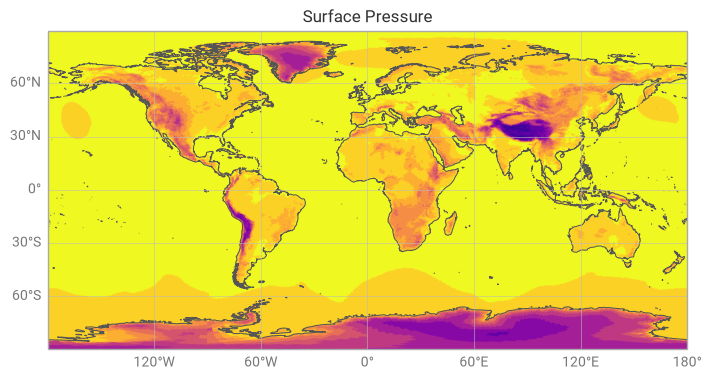

In [ ]:
chart = earthkit.plots.Map(extent=[-180, 180, -90, 90])
chart.grid_cells(
    df[0],
)

chart.title("Surface Pressure")
chart.coastlines()
chart.gridlines()
chart.show()

In [ ]:
# Regrid t=from healpix for conversion to xarray
data_latlon = data_latlon = regrid(df, out_grid={"grid": [1, 1]}, interpolation="linear")
# Convert data to xarray
data_latlon.to_xarray()

Cache file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-cab956f37b584714643beaa7b6c4e940.mat does not exist
Creating cache file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-cab956f37b584714643beaa7b6c4e940.mat
CacheManager creating file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-cab956f37b584714643beaa7b6c4e940.mat
Cache file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-e805d5262df6f8bec1056a788a5ecc3b.mat does not exist
Creating cache file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-e805d5262df6f8bec1056a788a5ecc3b.mat
CacheManager creating file /tmp/cache/mir/weights/18/linear/HN128/LL-1x1-90:0:-90:359-e805d5262df6f8bec1056a788a5ecc3b.mat


<xarray.Dataset> Size: 2MB
Dimensions:    (latitude: 181, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude  (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables:
    10u        (latitude, longitude) float64 521kB ...
    10v        (latitude, longitude) float64 521kB ...
    sp         (latitude, longitude) float64 521kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF